# MediaPipe Head Movement Pipeline Demo

This notebook implements two production-shaped classes:

- `MediapipeAnalyzer`: runs one MediaPipe Face Landmarker pass over a video and stores per-frame records.
- `HeadMovement`: consumes only the subset of MediaPipe output needed for head movement and returns the usual two dataframes: framewise output and one-row summary.

The notebook finishes by running both classes on a real video and showing analyzer previews plus head movement results in `raw` and `relative_smoothed` modes.


## 1. Config

Assumptions for this demo:

- `MediapipeAnalyzer` processes every frame exactly once in `VIDEO` mode.
- Frame records are stored as plain Python dictionaries so they are easy to persist or pass between components.
- `HeadMovement.analyze()` accepts only the narrowed subset exported by `MediapipeAnalyzer.export_head_movement_inputs()`.
- The default head-movement demo applies `yaw_sign=-1` because the current AFLW yaw-only benchmark showed that this convention is closer to the benchmark target.


In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import time
import urllib.request

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'openwillis-face').exists() and (ROOT.parent / 'openwillis-face').exists():
    ROOT = ROOT.parent

NOTEBOOK_DIR = ROOT / 'head_movement'
MODEL_DIR = NOTEBOOK_DIR / 'models'
MODEL_PATH = MODEL_DIR / 'face_landmarker.task'

CONFIG = {
    'video_path': ROOT / 'video.mov',
    'frames_per_second': 30,
    'normalize_by_bb_size': False,
    'neutral_window_seconds': 1.0,
    'ema_alpha': 0.3,
    'axis_signs': {'pitch': 1.0, 'roll': 1.0, 'yaw': -1.0},
    'transpose_matrix': False,
    'num_faces': 1,
    'min_face_detection_confidence': 0.5,
    'min_face_presence_confidence': 0.5,
    'min_tracking_confidence': 0.5,
    'output_face_blendshapes': True,
    'model_url': 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
    'model_path': MODEL_PATH,
}

assert CONFIG['video_path'].exists(), f"Missing video: {CONFIG['video_path']}"
CONFIG


{'video_path': PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/video.mov'),
 'frames_per_second': 30,
 'normalize_by_bb_size': False,
 'neutral_window_seconds': 1.0,
 'ema_alpha': 0.3,
 'axis_signs': {'pitch': 1.0, 'roll': 1.0, 'yaw': -1.0},
 'transpose_matrix': False,
 'num_faces': 1,
 'min_face_detection_confidence': 0.5,
 'min_face_presence_confidence': 0.5,
 'min_tracking_confidence': 0.5,
 'output_face_blendshapes': True,
 'model_url': 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
 'model_path': PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/head_movement/models/face_landmarker.task')}

## 2. Helpers and shared schema

In [2]:
FRAMEWISE_COLUMNS = [
    'frame',
    'bb_x1',
    'bb_y1',
    'bb_x2',
    'bb_y2',
    'face_confidence',
    'pitch',
    'roll',
    'yaw',
    'time',
    'bb_center_x',
    'bb_center_y',
    'euclidean_angle',
    'euclidean_angle_disp',
    'xy_disp',
]

SUMMARY_COLUMNS = [
    'xy_disp_mean',
    'pitch_mean',
    'yaw_mean',
    'roll_mean',
    'euclidean_angle_disp_mean',
    'xy_disp_std',
    'pitch_std',
    'yaw_std',
    'roll_std',
    'euclidean_angle_disp_std',
]


def clip_bbox_to_frame(bbox_xyxy: np.ndarray, width: int, height: int) -> np.ndarray:
    bbox = np.asarray(bbox_xyxy, dtype=np.float64).copy()
    bbox[[0, 2]] = np.clip(bbox[[0, 2]], 0.0, width - 1.0)
    bbox[[1, 3]] = np.clip(bbox[[1, 3]], 0.0, height - 1.0)
    if bbox[2] < bbox[0]:
        bbox[2] = bbox[0]
    if bbox[3] < bbox[1]:
        bbox[3] = bbox[1]
    return bbox


def orthonormalize_rotation(matrix: np.ndarray) -> np.ndarray:
    u, _, vh = np.linalg.svd(matrix)
    rotation = u @ vh
    if np.linalg.det(rotation) < 0:
        u[:, -1] *= -1.0
        rotation = u @ vh
    return rotation


def rotation_matrix_to_pitch_roll_yaw(rotation_matrix: np.ndarray) -> np.ndarray:
    rotation_matrix = orthonormalize_rotation(np.asarray(rotation_matrix, dtype=np.float64))
    sy = np.clip(rotation_matrix[0, 2], -1.0, 1.0)
    yaw = np.arcsin(sy)
    cy = np.cos(yaw)
    if abs(cy) > 1e-6:
        pitch = np.arctan2(-rotation_matrix[1, 2], rotation_matrix[2, 2])
        roll = np.arctan2(-rotation_matrix[0, 1], rotation_matrix[0, 0])
    else:
        pitch = np.arctan2(rotation_matrix[2, 1], rotation_matrix[1, 1])
        roll = 0.0
    return np.degrees([pitch, roll, yaw]).astype(float)


def compute_rotation_angles_vectorized(pitch: np.ndarray, yaw: np.ndarray, roll: np.ndarray, order: str = 'XYZ') -> np.ndarray:
    pitch_rad = np.radians(pitch)
    yaw_rad = np.radians(yaw)
    roll_rad = np.radians(roll)

    cos_p, sin_p = np.cos(pitch_rad), np.sin(pitch_rad)
    cos_y, sin_y = np.cos(yaw_rad), np.sin(yaw_rad)
    cos_r, sin_r = np.cos(roll_rad), np.sin(roll_rad)

    r_x = np.stack([
        np.stack([np.ones_like(pitch_rad), np.zeros_like(pitch_rad), np.zeros_like(pitch_rad)], axis=-1),
        np.stack([np.zeros_like(pitch_rad), cos_p, -sin_p], axis=-1),
        np.stack([np.zeros_like(pitch_rad), sin_p, cos_p], axis=-1),
    ], axis=1)

    r_y = np.stack([
        np.stack([cos_y, np.zeros_like(yaw_rad), sin_y], axis=-1),
        np.stack([np.zeros_like(yaw_rad), np.ones_like(yaw_rad), np.zeros_like(yaw_rad)], axis=-1),
        np.stack([-sin_y, np.zeros_like(yaw_rad), cos_y], axis=-1),
    ], axis=1)

    r_z = np.stack([
        np.stack([cos_r, -sin_r, np.zeros_like(roll_rad)], axis=-1),
        np.stack([sin_r, cos_r, np.zeros_like(roll_rad)], axis=-1),
        np.stack([np.zeros_like(roll_rad), np.zeros_like(roll_rad), np.ones_like(roll_rad)], axis=-1),
    ], axis=1)

    order_map = {
        'XYZ': lambda: np.einsum('nij,njk,nkl->nil', r_x, r_y, r_z),
        'YXZ': lambda: np.einsum('nij,njk,nkl->nil', r_y, r_x, r_z),
        'ZXY': lambda: np.einsum('nij,njk,nkl->nil', r_z, r_x, r_y),
        'ZYX': lambda: np.einsum('nij,njk,nkl->nil', r_z, r_y, r_x),
    }
    if order not in order_map:
        raise ValueError('Invalid rotation order')

    rotation_stack = order_map[order]()
    trace_r = np.einsum('nii->n', rotation_stack)
    rotation_angles = np.arccos(np.clip((trace_r - 1.0) / 2.0, -1.0, 1.0))
    return np.degrees(rotation_angles)


def compute_bb_centers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['bb_center_x'] = df[['bb_x1', 'bb_x2']].mean(axis=1)
    df['bb_center_y'] = df[['bb_y1', 'bb_y2']].mean(axis=1)
    return df


def get_fw_xy_displacement(sampled_frames: pd.DataFrame) -> pd.Series:
    valid_frames = sampled_frames[['bb_center_x', 'bb_center_y']].dropna()
    if len(valid_frames) < 2:
        return pd.Series(dtype=float)
    displacement_xy = valid_frames.diff()
    return (displacement_xy ** 2).sum(axis=1) ** 0.5


def compute_xy_disp(sampled_df: pd.DataFrame, normalize_by_bb_size: bool = False) -> pd.DataFrame:
    sampled_df = sampled_df.copy()
    sampled_df['xy_disp'] = get_fw_xy_displacement(sampled_df)
    if normalize_by_bb_size:
        sampled_df['xy_disp'] /= (sampled_df['bb_x2'] - sampled_df['bb_x1']).abs()
    return sampled_df


def compute_summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    stats_cols = ['xy_disp', 'pitch', 'yaw', 'roll', 'euclidean_angle_disp']
    mean_series = df[stats_cols].mean()
    std_series = df[stats_cols].std()
    summary_df = pd.DataFrame({
        'xy_disp_mean': [mean_series['xy_disp']],
        'pitch_mean': [mean_series['pitch']],
        'yaw_mean': [mean_series['yaw']],
        'roll_mean': [mean_series['roll']],
        'euclidean_angle_disp_mean': [mean_series['euclidean_angle_disp']],
        'xy_disp_std': [std_series['xy_disp']],
        'pitch_std': [std_series['pitch']],
        'yaw_std': [std_series['yaw']],
        'roll_std': [std_series['roll']],
        'euclidean_angle_disp_std': [std_series['euclidean_angle_disp']],
    })
    return summary_df[SUMMARY_COLUMNS]


def finalize_head_movement_df(df: pd.DataFrame, normalize_by_bb_size: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df = compute_bb_centers(df)
    sampled_frames = compute_xy_disp(df.copy(), normalize_by_bb_size=normalize_by_bb_size)
    df['euclidean_angle'] = compute_rotation_angles_vectorized(
        df['pitch'].to_numpy(dtype=float),
        df['yaw'].to_numpy(dtype=float),
        df['roll'].to_numpy(dtype=float),
    )
    sampled_angles = df['euclidean_angle'].dropna()
    df['euclidean_angle_disp'] = sampled_angles.diff().abs()
    df['xy_disp'] = sampled_frames['xy_disp']
    df = df[FRAMEWISE_COLUMNS]
    summary_df = compute_summary_stats(df)
    return df, summary_df


def compute_median_rotation(rotations: List[np.ndarray]) -> np.ndarray:
    stacked = np.stack(rotations, axis=0)
    median_matrix = np.median(stacked, axis=0)
    return orthonormalize_rotation(median_matrix)


def apply_ema_to_angles(angles: np.ndarray, alpha: float) -> np.ndarray:
    if len(angles) == 0:
        return angles.copy()
    smoothed = np.zeros_like(angles, dtype=np.float64)
    smoothed[0] = angles[0]
    for idx in range(1, len(angles)):
        smoothed[idx] = alpha * angles[idx] + (1.0 - alpha) * smoothed[idx - 1]
    return smoothed


def landmarks_to_numpy(face_landmarks) -> np.ndarray:
    return np.array([[landmark.x, landmark.y, landmark.z] for landmark in face_landmarks], dtype=np.float64)


def landmarks_to_bbox(landmarks_xyz: np.ndarray, width: int, height: int) -> np.ndarray:
    xs = landmarks_xyz[:, 0] * width
    ys = landmarks_xyz[:, 1] * height
    bbox = np.array([np.nanmin(xs), np.nanmin(ys), np.nanmax(xs), np.nanmax(ys)], dtype=np.float64)
    return clip_bbox_to_frame(bbox, width, height)


def blendshapes_to_dict(face_blendshapes) -> Dict[str, float]:
    return {item.category_name: float(item.score) for item in face_blendshapes}


## 3. Production-shaped classes

In [3]:
@dataclass
class VideoMeta:
    video_path: str
    num_frames: int
    video_fps: float
    width: int
    height: int


class MediapipeAnalyzer:
    def __init__(
        self,
        model_path: Path,
        model_url: str,
        num_faces: int = 1,
        min_face_detection_confidence: float = 0.5,
        min_face_presence_confidence: float = 0.5,
        min_tracking_confidence: float = 0.5,
        output_face_blendshapes: bool = True,
        output_facial_transformation_matrixes: bool = True,
    ) -> None:
        self.model_path = Path(model_path)
        self.model_url = model_url
        self.num_faces = num_faces
        self.min_face_detection_confidence = min_face_detection_confidence
        self.min_face_presence_confidence = min_face_presence_confidence
        self.min_tracking_confidence = min_tracking_confidence
        self.output_face_blendshapes = output_face_blendshapes
        self.output_facial_transformation_matrixes = output_facial_transformation_matrixes

        self.records: List[dict] = []
        self.video_meta: Optional[VideoMeta] = None
        self.run_info: Dict[str, object] = {}
        self.first_valid_overlay: Optional[dict] = None

    def ensure_model(self) -> Path:
        self.model_path.parent.mkdir(parents=True, exist_ok=True)
        if not self.model_path.exists():
            urllib.request.urlretrieve(self.model_url, self.model_path)
        return self.model_path

    def _create_face_landmarker(self):
        base_options = mp.tasks.BaseOptions(model_asset_path=str(self.ensure_model()))
        options = mp.tasks.vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=mp.tasks.vision.RunningMode.VIDEO,
            num_faces=self.num_faces,
            min_face_detection_confidence=self.min_face_detection_confidence,
            min_face_presence_confidence=self.min_face_presence_confidence,
            min_tracking_confidence=self.min_tracking_confidence,
            output_face_blendshapes=self.output_face_blendshapes,
            output_facial_transformation_matrixes=self.output_facial_transformation_matrixes,
        )
        return mp.tasks.vision.FaceLandmarker.create_from_options(options)

    def analyze(self, video_path: Path) -> List[dict]:
        video_path = Path(video_path)
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            raise IOError(f'Cannot open video file: {video_path}')

        num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        video_fps = float(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.video_meta = VideoMeta(
            video_path=str(video_path),
            num_frames=num_frames,
            video_fps=video_fps,
            width=width,
            height=height,
        )

        self.records = []
        self.first_valid_overlay = None
        frame_index = 0
        start_time = time.perf_counter()

        with self._create_face_landmarker() as landmarker:
            while True:
                ret, frame_bgr = cap.read()
                if not ret:
                    break

                timestamp_ms = int(round((frame_index / video_fps) * 1000.0))
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
                result = landmarker.detect_for_video(mp_image, timestamp_ms)

                face_count = len(result.face_landmarks)
                selected_face_index = 0 if face_count == 1 else None
                valid_for_head_pose = False
                failure_reason = None
                bbox_xyxy_px = None
                bb_center_x = None
                bb_center_y = None
                face_width_px = None
                face_height_px = None
                face_scale_px = None
                landmarks_norm_xyz = None
                transform_matrix_4x4 = None
                blendshapes = None

                if face_count == 1:
                    landmarks_xyz = landmarks_to_numpy(result.face_landmarks[0])
                    bbox = landmarks_to_bbox(landmarks_xyz, width, height)
                    landmarks_norm_xyz = landmarks_xyz.tolist()
                    bbox_xyxy_px = bbox.tolist()
                    bb_center_x = float((bbox[0] + bbox[2]) / 2.0)
                    bb_center_y = float((bbox[1] + bbox[3]) / 2.0)
                    face_width_px = float(abs(bbox[2] - bbox[0]))
                    face_height_px = float(abs(bbox[3] - bbox[1]))
                    face_scale_px = float(max(face_width_px, face_height_px))
                    if self.output_facial_transformation_matrixes and len(result.facial_transformation_matrixes) == 1:
                        matrix4x4 = np.asarray(result.facial_transformation_matrixes[0], dtype=np.float64).reshape(4, 4)
                        transform_matrix_4x4 = matrix4x4.tolist()
                        valid_for_head_pose = True
                    else:
                        failure_reason = 'missing_transformation_matrix'

                    if self.output_face_blendshapes and len(result.face_blendshapes) == 1:
                        blendshapes = blendshapes_to_dict(result.face_blendshapes[0])

                    if valid_for_head_pose and self.first_valid_overlay is None:
                        self.first_valid_overlay = {
                            'frame_index': frame_index,
                            'frame_rgb': frame_rgb.copy(),
                            'landmarks_xyz': landmarks_xyz.copy(),
                            'bbox_xyxy': bbox.copy(),
                        }
                else:
                    failure_reason = f'face_count={face_count}'

                record = {
                    'frame_index': frame_index,
                    'timestamp_ms': timestamp_ms,
                    'time_seconds': frame_index / video_fps,
                    'face_count': face_count,
                    'selected_face_index': selected_face_index,
                    'valid_for_head_pose': valid_for_head_pose,
                    'failure_reason': failure_reason,
                    'bbox_xyxy_px': bbox_xyxy_px,
                    'bb_center_x': bb_center_x,
                    'bb_center_y': bb_center_y,
                    'face_width_px': face_width_px,
                    'face_height_px': face_height_px,
                    'face_scale_px': face_scale_px,
                    'landmarks_norm_xyz': landmarks_norm_xyz,
                    'transform_matrix_4x4': transform_matrix_4x4,
                    'blendshapes': blendshapes,
                }
                self.records.append(record)
                frame_index += 1

        cap.release()
        total_ms = (time.perf_counter() - start_time) * 1000.0
        valid_frames = sum(int(record['valid_for_head_pose']) for record in self.records)
        self.run_info = {
            'total_ms': total_ms,
            'ms_per_source_frame': total_ms / max(1, num_frames),
            'valid_head_pose_frames': valid_frames,
            'missing_head_pose_frames': num_frames - valid_frames,
            'detection_rate': valid_frames / max(1, num_frames),
        }
        return self.records

    def records_to_dataframe(self, max_rows: Optional[int] = None) -> pd.DataFrame:
        preview_rows = []
        for record in self.records:
            preview_rows.append({
                'frame_index': record['frame_index'],
                'time_seconds': record['time_seconds'],
                'face_count': record['face_count'],
                'valid_for_head_pose': record['valid_for_head_pose'],
                'failure_reason': record['failure_reason'],
                'bb_center_x': record['bb_center_x'],
                'bb_center_y': record['bb_center_y'],
                'face_scale_px': record['face_scale_px'],
                'has_landmarks': record['landmarks_norm_xyz'] is not None,
                'has_transform_matrix': record['transform_matrix_4x4'] is not None,
                'blendshape_count': len(record['blendshapes']) if record['blendshapes'] is not None else 0,
            })
        df = pd.DataFrame(preview_rows)
        return df if max_rows is None else df.head(max_rows)

    def export_head_movement_inputs(self) -> List[dict]:
        return [
            {
                'frame_index': record['frame_index'],
                'timestamp_ms': record['timestamp_ms'],
                'time_seconds': record['time_seconds'],
                'face_count': record['face_count'],
                'valid_for_head_pose': record['valid_for_head_pose'],
                'failure_reason': record['failure_reason'],
                'bbox_xyxy_px': record['bbox_xyxy_px'],
                'transform_matrix_4x4': record['transform_matrix_4x4'],
            }
            for record in self.records
        ]

    def show_first_valid_overlay(self) -> None:
        if self.first_valid_overlay is None:
            raise ValueError('No valid overlay available. Run analyze() first.')
        payload = self.first_valid_overlay
        frame_rgb = payload['frame_rgb']
        landmarks_xyz = payload['landmarks_xyz']
        bbox = payload['bbox_xyxy']

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(frame_rgb)
        ax.scatter(
            landmarks_xyz[:, 0] * frame_rgb.shape[1],
            landmarks_xyz[:, 1] * frame_rgb.shape[0],
            s=4,
            c='lime',
        )
        rect = plt.Rectangle(
            (bbox[0], bbox[1]),
            bbox[2] - bbox[0],
            bbox[3] - bbox[1],
            fill=False,
            edgecolor='yellow',
            linewidth=2,
        )
        ax.add_patch(rect)
        ax.set_title(f"First valid MediaPipe frame: {payload['frame_index']}")
        ax.axis('off')
        plt.tight_layout()
        plt.show()


class HeadMovement:
    def __init__(
        self,
        normalize_by_bb_size: bool = False,
        neutral_window_seconds: float = 1.0,
        ema_alpha: float = 0.3,
        axis_signs: Optional[Dict[str, float]] = None,
        transpose_matrix: bool = False,
    ) -> None:
        self.normalize_by_bb_size = normalize_by_bb_size
        self.neutral_window_seconds = neutral_window_seconds
        self.ema_alpha = ema_alpha
        self.axis_signs = axis_signs or {'pitch': 1.0, 'roll': 1.0, 'yaw': 1.0}
        self.transpose_matrix = transpose_matrix
        self.last_debug_info: Dict[str, object] = {}

    def _empty_facepose_row(self, frame_index: int) -> np.ndarray:
        return np.array([frame_index, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)

    def _make_facepose_row(self, frame_index: int, bbox_xyxy: np.ndarray, pose_pry: np.ndarray, face_confidence: float = 1.0) -> np.ndarray:
        return np.array([
            frame_index,
            bbox_xyxy[0],
            bbox_xyxy[1],
            bbox_xyxy[2],
            bbox_xyxy[3],
            face_confidence,
            pose_pry[0],
            pose_pry[1],
            pose_pry[2],
        ], dtype=float)

    def _rotation_from_record(self, record: dict) -> Optional[np.ndarray]:
        matrix4x4 = record.get('transform_matrix_4x4')
        if matrix4x4 is None:
            return None
        rotation = np.asarray(matrix4x4, dtype=np.float64).reshape(4, 4)[:3, :3]
        if self.transpose_matrix:
            rotation = rotation.T
        return orthonormalize_rotation(rotation)

    def _apply_axis_signs(self, pose_pry: np.ndarray) -> np.ndarray:
        signs = np.array([
            self.axis_signs.get('pitch', 1.0),
            self.axis_signs.get('roll', 1.0),
            self.axis_signs.get('yaw', 1.0),
        ], dtype=np.float64)
        return np.asarray(pose_pry, dtype=np.float64) * signs

    def _pose_from_rotation(self, rotation: np.ndarray) -> np.ndarray:
        pose = rotation_matrix_to_pitch_roll_yaw(rotation)
        return self._apply_axis_signs(pose)

    def _build_raw_rows(self, records: Sequence[dict], meta: VideoMeta, frames_per_second: float) -> Tuple[List[np.ndarray], Dict[int, np.ndarray], dict]:
        skip_interval = max(1, int(meta.video_fps / frames_per_second))
        rows = [self._empty_facepose_row(frame_index) for frame_index in range(meta.num_frames)]
        rotations_by_frame: Dict[int, np.ndarray] = {}
        sampled_frame_count = 0
        valid_sampled_pose_frames = 0

        for record in records:
            frame_index = int(record['frame_index'])
            if frame_index % skip_interval != 0:
                continue
            sampled_frame_count += 1
            rotation = self._rotation_from_record(record)
            bbox_xyxy = record.get('bbox_xyxy_px')
            if record.get('valid_for_head_pose') and rotation is not None and bbox_xyxy is not None:
                pose_pry = self._pose_from_rotation(rotation)
                rows[frame_index] = self._make_facepose_row(frame_index, np.asarray(bbox_xyxy, dtype=np.float64), pose_pry, face_confidence=1.0)
                rotations_by_frame[frame_index] = rotation
                valid_sampled_pose_frames += 1

        debug_info = {
            'skip_interval': skip_interval,
            'sampled_frame_count': sampled_frame_count,
            'valid_sampled_pose_frames': valid_sampled_pose_frames,
        }
        return rows, rotations_by_frame, debug_info

    def _build_relative_smoothed_rows(self, rows: List[np.ndarray], rotations_by_frame: Dict[int, np.ndarray], meta: VideoMeta) -> Tuple[List[np.ndarray], dict]:
        relative_rows = [row.copy() for row in rows]
        valid_frames = sorted(rotations_by_frame.keys())
        if not valid_frames:
            return relative_rows, {'baseline_frames': [], 'baseline_rotation': None}

        baseline_frames = [frame for frame in valid_frames if (frame / meta.video_fps) <= self.neutral_window_seconds]
        if not baseline_frames:
            baseline_frames = valid_frames[:1]

        baseline_rotation = compute_median_rotation([rotations_by_frame[frame] for frame in baseline_frames])
        calibrated_angles = []
        for frame in valid_frames:
            delta_rotation = rotations_by_frame[frame] @ baseline_rotation.T
            calibrated_angles.append(self._pose_from_rotation(delta_rotation))
        calibrated_angles = np.asarray(calibrated_angles, dtype=np.float64)
        smoothed_angles = apply_ema_to_angles(calibrated_angles, alpha=self.ema_alpha)

        for frame, pose_pry in zip(valid_frames, smoothed_angles):
            relative_rows[frame][6:9] = pose_pry

        debug_info = {
            'baseline_frames': baseline_frames,
            'baseline_rotation': baseline_rotation,
        }
        return relative_rows, debug_info

    def analyze(
        self,
        records: Sequence[dict],
        video_meta: VideoMeta,
        frames_per_second: float = 3,
        pose_variant: str = 'relative_smoothed',
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        if pose_variant not in {'raw', 'relative_smoothed'}:
            raise ValueError(f'Unsupported pose_variant: {pose_variant}')

        start_time = time.perf_counter()
        rows, rotations_by_frame, debug_info = self._build_raw_rows(records, video_meta, frames_per_second)

        if pose_variant == 'relative_smoothed':
            rows, relative_debug = self._build_relative_smoothed_rows(rows, rotations_by_frame, video_meta)
            debug_info.update(relative_debug)
        else:
            debug_info.update({'baseline_frames': [], 'baseline_rotation': None})

        out_array = np.asarray(rows, dtype=float)
        out_df = pd.DataFrame(
            out_array,
            columns=['frame', 'bb_x1', 'bb_y1', 'bb_x2', 'bb_y2', 'face_confidence', 'pitch', 'roll', 'yaw'],
        )
        out_df['time'] = out_df['frame'] / video_meta.video_fps
        out_df, summary_df = finalize_head_movement_df(out_df, normalize_by_bb_size=self.normalize_by_bb_size)

        total_ms = (time.perf_counter() - start_time) * 1000.0
        self.last_debug_info = {
            'pose_variant': pose_variant,
            'total_ms': total_ms,
            'ms_per_source_frame': total_ms / max(1, video_meta.num_frames),
            'ms_per_sampled_frame': total_ms / max(1, debug_info['sampled_frame_count']),
            **debug_info,
        }
        return out_df, summary_df


## 4. Run `MediapipeAnalyzer`

In [4]:
analyzer = MediapipeAnalyzer(
    model_path=CONFIG['model_path'],
    model_url=CONFIG['model_url'],
    num_faces=CONFIG['num_faces'],
    min_face_detection_confidence=CONFIG['min_face_detection_confidence'],
    min_face_presence_confidence=CONFIG['min_face_presence_confidence'],
    min_tracking_confidence=CONFIG['min_tracking_confidence'],
    output_face_blendshapes=CONFIG['output_face_blendshapes'],
    output_facial_transformation_matrixes=True,
)

mediapipe_records = analyzer.analyze(CONFIG['video_path'])
head_movement_inputs = analyzer.export_head_movement_inputs()

meta_df = pd.DataFrame([asdict(analyzer.video_meta)])
run_info_df = pd.DataFrame([analyzer.run_info])
records_preview_df = analyzer.records_to_dataframe(max_rows=12)

print(f'Records collected: {len(mediapipe_records)}')
display(meta_df)
display(run_info_df)
display(records_preview_df)
display(pd.Series([record['failure_reason'] for record in mediapipe_records]).value_counts(dropna=False).rename_axis('failure_reason').to_frame('count'))
print('HeadMovement input keys:', sorted(head_movement_inputs[0].keys()))


I0000 00:00:1780045993.942313 10590803 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1780045993.943482 10590803 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780045993.952412 10591835 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780045993.960734 10591832 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780045993.989420 10591833 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Records collected: 644


,video_path,num_frames,video_fps,width,height
0,/Users/pelmeshek1706/Desktop/projects/airest-f...,644,30.0,1920,1080


,total_ms,ms_per_source_frame,valid_head_pose_frames,missing_head_pose_frames,detection_rate
0,10274.160334,15.953665,644,0,1.0


,frame_index,time_seconds,face_count,valid_for_head_pose,failure_reason,bb_center_x,bb_center_y,face_scale_px,has_landmarks,has_transform_matrix,blendshape_count
0,0,0.000000,1,True,None,1001.328421,480.048122,464.729147,True,True,52
1,1,0.033333,1,True,None,1000.783625,480.510836,478.289194,True,True,52
2,2,0.066667,1,True,None,1000.777388,480.838012,482.247684,True,True,52
3,3,0.100000,1,True,None,1001.186314,481.851999,484.198090,True,True,52
4,4,0.133333,1,True,None,1001.643276,482.407780,486.045628,True,True,52
5,5,0.166667,1,True,None,1001.844950,482.454321,487.898283,True,True,52
6,6,0.200000,1,True,None,1001.738005,482.783895,489.381598,True,True,52
7,7,0.233333,1,True,None,1001.290340,482.757575,490.655395,True,True,52
8,8,0.266667,1,True,None,1000.936031,482.234544,491.841275,True,True,52
9,9,0.300000,1,True,None,1000.739594,481.338906,492.774716,True,True,52


,count
failure_reason,
None,644


HeadMovement input keys: ['bbox_xyxy_px', 'face_count', 'failure_reason', 'frame_index', 'time_seconds', 'timestamp_ms', 'transform_matrix_4x4', 'valid_for_head_pose']


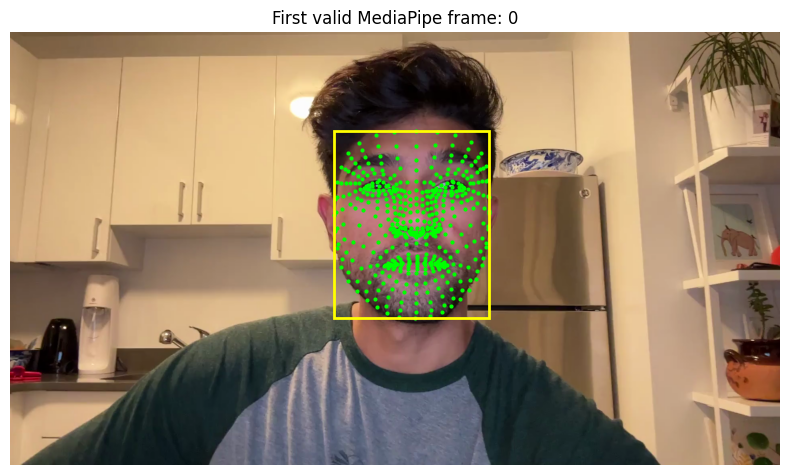

In [5]:
analyzer.show_first_valid_overlay()

## 5. Run `HeadMovement`

In [6]:
head_movement = HeadMovement(
    normalize_by_bb_size=CONFIG['normalize_by_bb_size'],
    neutral_window_seconds=CONFIG['neutral_window_seconds'],
    ema_alpha=CONFIG['ema_alpha'],
    axis_signs=CONFIG['axis_signs'],
    transpose_matrix=CONFIG['transpose_matrix'],
)

raw_df, raw_summary_df = head_movement.analyze(
    head_movement_inputs,
    analyzer.video_meta,
    frames_per_second=CONFIG['frames_per_second'],
    pose_variant='raw',
)
raw_debug = dict(head_movement.last_debug_info)

relative_df, relative_summary_df = head_movement.analyze(
    head_movement_inputs,
    analyzer.video_meta,
    frames_per_second=CONFIG['frames_per_second'],
    pose_variant='relative_smoothed',
)
relative_debug = dict(head_movement.last_debug_info)

print('HeadMovement raw debug:')
display(pd.DataFrame([raw_debug]))
print('HeadMovement relative_smoothed debug:')
display(pd.DataFrame([relative_debug]))
print('Raw framewise output preview:')
display(raw_df.head(12))
print('Raw summary:')
display(raw_summary_df)
print('Relative_smoothed framewise output preview:')
display(relative_df.head(12))
print('Relative_smoothed summary:')
display(relative_summary_df)


HeadMovement raw debug:


,pose_variant,total_ms,ms_per_source_frame,ms_per_sampled_frame,skip_interval,sampled_frame_count,valid_sampled_pose_frames,baseline_frames,baseline_rotation
0,raw,36.243375,0.056279,0.056279,1,644,644,[],None


HeadMovement relative_smoothed debug:


,pose_variant,total_ms,ms_per_source_frame,ms_per_sampled_frame,skip_interval,sampled_frame_count,valid_sampled_pose_frames,baseline_frames,baseline_rotation
0,relative_smoothed,51.352667,0.07974,0.07974,1,644,644,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.9992551438013033, -0.006596608459336062, 0..."


Raw framewise output preview:


...

,xy_disp_mean,pitch_mean,yaw_mean,roll_mean,euclidean_angle_disp_mean,xy_disp_std,pitch_std,yaw_std,roll_std,euclidean_angle_disp_std
0,3.159864,2.09601,1.034108,-3.826325,0.592499,2.610221,6.051301,4.581241,2.252905,0.70181


Relative_smoothed framewise output preview:


,frame,bb_x1,bb_y1,bb_x2,bb_y2,face_confidence,pitch,roll,yaw,time,bb_center_x,bb_center_y,euclidean_angle,euclidean_angle_disp,xy_disp
0,0.0,807.879009,247.683549,1194.777832,712.412696,1.0,1.490411,-0.104398,0.566401,0.000000,1001.328421,480.048122,1.597335,NaN,0.000000
1,1.0,807.205753,241.366239,1194.361496,719.655433,1.0,1.455860,-0.087382,0.537364,0.033333,1000.783625,480.510836,1.553935,0.043399,0.714777
2,2.0,806.878681,239.714170,1194.676094,721.961854,1.0,1.427844,-0.063362,0.488416,0.066667,1000.777388,480.838012,1.510139,0.043796,0.327235
3,3.0,806.815109,239.752954,1195.557518,723.951044,1.0,1.405966,-0.029358,0.453470,0.100000,1001.186314,481.851999,1.477464,0.032675,1.093340
4,4.0,806.817856,239.384966,1196.468697,725.430593,1.0,1.390813,0.004714,0.405713,0.133333,1001.643276,482.407780,1.448801,0.028663,0.719518
5,5.0,806.795139,238.505180,1196.894760,726.403463,1.0,1.327565,0.045335,0.347469,0.166667,1001.844950,482.454321,1.373163,0.075638,0.206974
6,6.0,806.451359,238.093096,1197.024651,727.474694,1.0,1.250679,0.070290,0.294766,0.200000,1001.738005,482.783895,1.287041,0.086122,0.346491
7,7.0,805.509338,237.429877,1197.071342,728.085272,1.0,1.141827,0.088099,0.250770,0.233333,1001.290340,482.757575,1.172541,0.114500,0.448437
8,8.0,804.820633,236.313906,1197.051430,728.155181,1.0,0.999530,0.102035,0.214953,0.266667,1000.936031,482.234544,1.027647,0.144895,0.631741
9,9.0,804.608688,234.951548,1196.870499,727.726264,1.0,0.806049,0.102319,0.178573,0.300000,1000.739594,481.338906,0.832063,0.195584,0.916927


Relative_smoothed summary:


,xy_disp_mean,pitch_mean,yaw_mean,roll_mean,euclidean_angle_disp_mean,xy_disp_std,pitch_std,yaw_std,roll_std,euclidean_angle_disp_std
0,3.159864,5.639871,3.462283,-3.985412,0.504049,2.610221,5.584744,4.352283,2.03012,0.481611


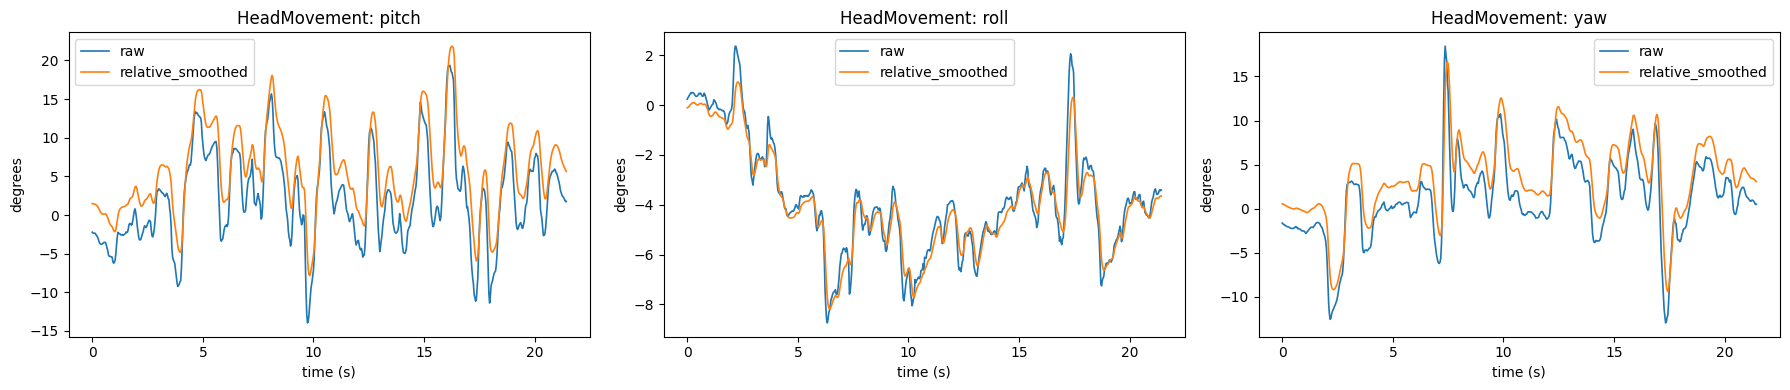

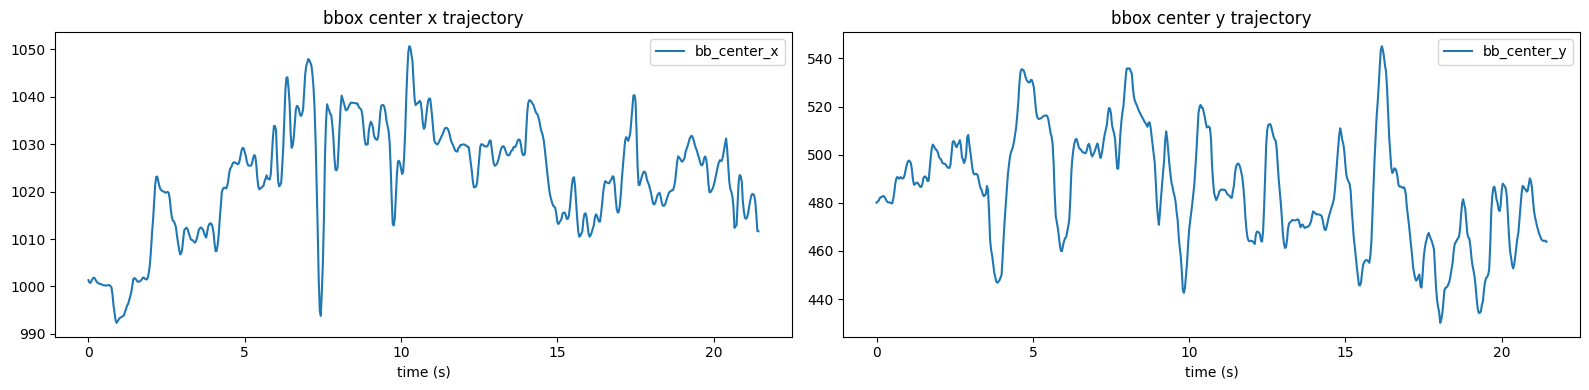

In [7]:
def plot_raw_vs_relative(raw_df: pd.DataFrame, relative_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    for ax, metric in zip(axes, ['pitch', 'roll', 'yaw']):
        raw_sampled = raw_df[['time', metric]].dropna()
        relative_sampled = relative_df[['time', metric]].dropna()
        ax.plot(raw_sampled['time'], raw_sampled[metric], label='raw', linewidth=1.2)
        ax.plot(relative_sampled['time'], relative_sampled[metric], label='relative_smoothed', linewidth=1.2)
        ax.set_title(f'HeadMovement: {metric}')
        ax.set_xlabel('time (s)')
        ax.set_ylabel('degrees')
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_bbox_trajectory(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
    sampled = df[['time', 'bb_center_x', 'bb_center_y']].dropna()
    axes[0].plot(sampled['time'], sampled['bb_center_x'], label='bb_center_x')
    axes[1].plot(sampled['time'], sampled['bb_center_y'], label='bb_center_y')
    axes[0].set_title('bbox center x trajectory')
    axes[1].set_title('bbox center y trajectory')
    for ax in axes:
        ax.set_xlabel('time (s)')
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_raw_vs_relative(raw_df, relative_df)
plot_bbox_trajectory(raw_df)


In [8]:
benchmark_df = pd.DataFrame([
    {
        'pipeline': 'mediapipe_analyzer',
        'total_ms': analyzer.run_info['total_ms'],
        'ms_per_source_frame': analyzer.run_info['ms_per_source_frame'],
        'ms_per_sampled_frame': analyzer.run_info['total_ms'] / max(1, raw_debug['sampled_frame_count']),
    },
    {
        'pipeline': 'head_movement.raw',
        'total_ms': raw_debug['total_ms'],
        'ms_per_source_frame': raw_debug['ms_per_source_frame'],
        'ms_per_sampled_frame': raw_debug['ms_per_sampled_frame'],
    },
    {
        'pipeline': 'head_movement.relative_smoothed',
        'total_ms': relative_debug['total_ms'],
        'ms_per_source_frame': relative_debug['ms_per_source_frame'],
        'ms_per_sampled_frame': relative_debug['ms_per_sampled_frame'],
    },
]).sort_values('total_ms')

benchmark_df


,pipeline,total_ms,ms_per_source_frame,ms_per_sampled_frame
1,head_movement.raw,36.243375,0.056279,0.056279
2,head_movement.relative_smoothed,51.352667,0.079740,0.079740
0,mediapipe_analyzer,10274.160334,15.953665,15.953665
